# Stack Exchange question-thread EDA

**Objective.** Describe one site and one question period, identify human response patterns, and select useful cases for later qualitative analysis.

**Audience.** A supervisor, intern, or researcher discovering the project for the first time.

**Scope.** Each table row represents one Stack Exchange question. Human-response indicators remain descriptive evidence. Difficulty labels are created later through a separate annotation protocol.

## Where the data comes from

- Stack Exchange publishes public data dumps as XML files.
- `Posts.xml` stores questions and answers. `PostTypeId = 1` means question; `PostTypeId = 2` means answer.
- `Comments.xml` stores comments separately. This project counts comments attached directly to questions.
- `Votes.xml` records the day on which an answer received an acceptance vote. An accepted answer is the solution selected by the question author.
- `build_characteristics.py` combines these sources into one tab-separated file. Each row describes one question, its content, and later human activity.

The dump is a snapshot. Titles, bodies, tags, scores, and view counts reflect the saved snapshot and may include activity or edits that occurred after posting. The notebook keeps question content, later human evidence, and dump-snapshot values conceptually separate.

In [1]:
# Libraries used for tables, statistics, and plots.
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

## Editable settings

Edit **only the next cell** when applying this notebook to another compatible table.

- **`DATA_FILE`** — the TSV produced by `build_characteristics.py`. Example for the other site: `Path("../data/processed/softwareengineering-2024/thread_characteristics.tsv")`.
- **`MIN_TAG_QUESTIONS`** — minimum number of questions required before a tag receives an outcome comparison. Lower values show more tags with less stable percentages. Example: change `20` to `10` for a small pilot.
- **`TOP_TAGS_TO_SHOW`** — maximum number of frequent tags shown in Figure 4 and tag comparisons. Example: change `15` to `10` for a shorter plot.
- **`MIN_ABSOLUTE_RHO`** — smallest Spearman relationship displayed in Figure 6. `0.30` keeps relationships with at least a moderate visible rank association.
- **`FDR_ALPHA`** — false-discovery-rate limit used while checking many correlations. `0.05` is the standard project setting.
- **`MAX_CASES_TO_SHOW`** — maximum number of questions shown in the final inspection table.

In [2]:
# Path to the characteristic table analyzed by this run.
DATA_FILE = Path("../data/processed/superuser-2024/thread_characteristics.tsv")

# Display and evidence-selection choices.
MIN_TAG_QUESTIONS = 20
TOP_TAGS_TO_SHOW = 15
MIN_ABSOLUTE_RHO = 0.30
FDR_ALPHA = 0.05
MAX_CASES_TO_SHOW = 8

## 1. Load and verify the table

This step checks that the required fields exist, converts dates and numbers to usable types, and prints a compact description of the selected data. A clear error stops the notebook when the input does not match the documented schema.

In [3]:
if not DATA_FILE.is_file():
    raise FileNotFoundError(f"Characteristic table not found: {DATA_FILE.resolve()}")

data = pd.read_csv(DATA_FILE, sep="\t", low_memory=False)

required_columns = {
    "site", "dump_snapshot_date", "question_id", "question_url",
    "question_creation_datetime", "question_title", "question_tags",
    "question_score", "question_view_count", "question_word_count",
    "available_answer_count", "has_available_answer",
    "first_answer_creation_datetime", "time_to_first_answer_hours",
    "accepted_answer_id", "acceptance_date", "closed_datetime",
    "available_question_comment_count", "code_line_count", "link_count",
    "image_count", "tag_count", "observation_days_at_dump",
}
missing_columns = sorted(required_columns - set(data.columns))
if missing_columns:
    raise ValueError("Missing required column(s): " + ", ".join(missing_columns))

# Convert source dates. Empty date fields remain missing values.
date_columns = [
    "dump_snapshot_date", "question_creation_datetime",
    "first_answer_creation_datetime", "acceptance_date", "closed_datetime",
]
for column in date_columns:
    data[column] = pd.to_datetime(data[column], errors="raise")

# Convert the measurements used by the analysis.
numeric_columns = [
    "question_score", "question_view_count", "question_word_count",
    "available_answer_count", "time_to_first_answer_hours",
    "available_question_comment_count", "code_line_count", "link_count",
    "image_count", "tag_count", "observation_days_at_dump",
]
for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors="raise")

# The TSV stores booleans as TRUE/FALSE for readability.
boolean_text = data["has_available_answer"].astype("string").str.upper()
invalid_booleans = boolean_text[~boolean_text.isin(["TRUE", "FALSE"])]
if not invalid_booleans.empty:
    raise ValueError("has_available_answer contains a value other than TRUE or FALSE")
data["has_available_answer"] = boolean_text.map({"TRUE": True, "FALSE": False})

data["has_accepted_answer"] = data["accepted_answer_id"].notna()
data["is_closed"] = data["closed_datetime"].notna()
data["question_month"] = data["question_creation_datetime"].dt.to_period("M").dt.to_timestamp()

sites = data["site"].dropna().unique()
if len(sites) != 1:
    raise ValueError(f"Expected one site, found {len(sites)}")

summary = pd.DataFrame({
    "Item": ["Site", "Questions", "Columns", "Question period", "Dump snapshot"],
    "Value": [
        sites[0],
        f"{len(data):,}",
        f"{len(data.columns):,}",
        f"{data['question_creation_datetime'].min():%Y-%m-%d} to {data['question_creation_datetime'].max():%Y-%m-%d}",
        f"{data['dump_snapshot_date'].max():%Y-%m-%d}",
    ],
})
display(summary)

,Item,Value
0,Site,superuser.com
1,Questions,"11,578"
2,Columns,50
3,Question period,2024-01-01 to 2024-12-31
4,Dump snapshot,2026-04-20


## 2. Overall human-response outcomes

Figure 1 counts questions that reached several observable outcomes by the dump snapshot.

- **Answered** means that at least one answer row is available in `Posts.xml`.
- **Accepted answer** means that the question identifies an author-selected solution.
- **Closed** means that Stack Exchange records the question as closed.

These groups overlap. For example, one question can be both answered and closed.

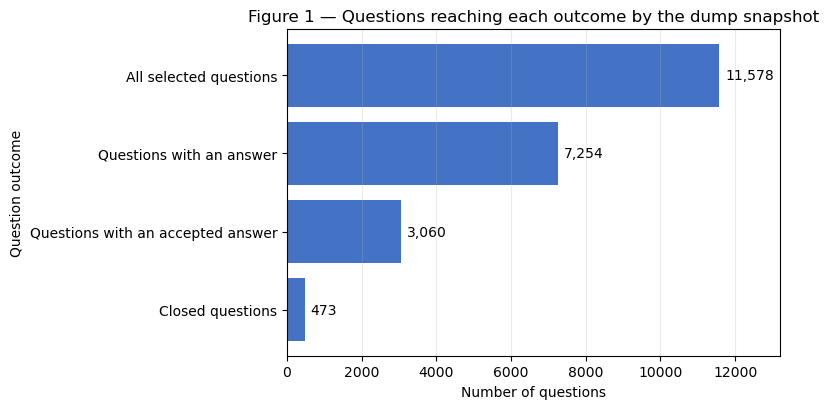

**Figure 1 interpretation**  
- **Answered:** 7,254 questions (62.7%).  
- **Accepted:** 3,060 questions (26.4%) have an author-selected solution.  
- **Closed:** 473 questions (4.1%) are recorded as closed.  
- These outcomes are useful human-response signals and remain separate from a difficulty label.

In [4]:
status_counts = pd.Series({
    "All selected questions": len(data),
    "Questions with an answer": int(data["has_available_answer"].sum()),
    "Questions with an accepted answer": int(data["has_accepted_answer"].sum()),
    "Closed questions": int(data["is_closed"].sum()),
})

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(status_counts.index, status_counts.values, color="#4472C4")
ax.invert_yaxis()
ax.set_title("Figure 1 — Questions reaching each outcome by the dump snapshot")
ax.set_xlabel("Number of questions")
ax.set_ylabel("Question outcome")
ax.grid(axis="x", alpha=0.25)
ax.bar_label(bars, labels=[f"{value:,}" for value in status_counts.values], padding=4)
ax.set_xlim(0, status_counts.max() * 1.14)
plt.tight_layout()
plt.show()

total = len(data)
display(Markdown(
    f"**Figure 1 interpretation**  \n"
    f"- **Answered:** {status_counts['Questions with an answer']:,} questions "
    f"({status_counts['Questions with an answer'] / total:.1%}).  \n"
    f"- **Accepted:** {status_counts['Questions with an accepted answer']:,} questions "
    f"({status_counts['Questions with an accepted answer'] / total:.1%}) have an author-selected solution.  \n"
    f"- **Closed:** {status_counts['Closed questions']:,} questions "
    f"({status_counts['Closed questions'] / total:.1%}) are recorded as closed.  \n"
    "- These outcomes are useful human-response signals and remain separate from a difficulty label."
))

## 3. Cumulative monthly evolution

Figure 2 follows the selected questions through calendar time. Every point includes the current month **and every earlier month**.

- The question line grows when a selected question is posted.
- The first-answer line grows when one of those questions receives its earliest available answer.
- The acceptance line grows on the recorded acceptance day.
- The closed line grows on the recorded closing date.

This event-based view prevents each month from being interpreted as an isolated batch.

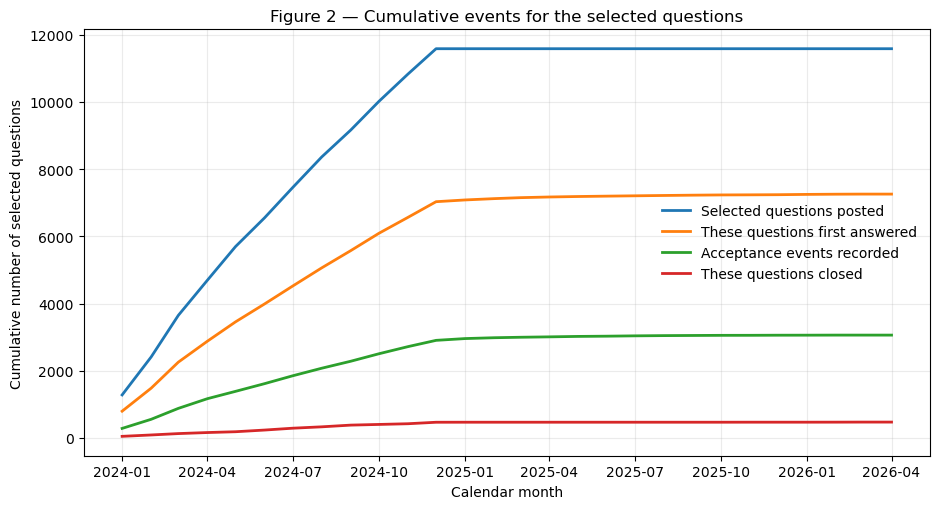

**Figure 2 interpretation**  
- The timeline starts in **January 2024** and continues to the **April 2026** dump snapshot.  
- By the snapshot, **7,254** selected questions had received a first answer.  
- **3,060** had a recorded acceptance event and **473** had a recorded closing event.  
- A flat segment means that no new selected question reached that event during those months.

In [5]:
event_dates = {
    "Selected questions posted": data["question_creation_datetime"],
    "These questions first answered": data["first_answer_creation_datetime"],
    "Acceptance events recorded": data["acceptance_date"],
    "These questions closed": data["closed_datetime"],
}

first_month = data["question_creation_datetime"].min().to_period("M").to_timestamp()
last_month = data["dump_snapshot_date"].max().to_period("M").to_timestamp()
months = pd.date_range(first_month, last_month, freq="MS")
monthly_events = pd.DataFrame(index=months)

for label, dates in event_dates.items():
    event_months = dates.dropna().dt.to_period("M").dt.to_timestamp()
    monthly_events[label] = event_months.value_counts().reindex(months, fill_value=0)

cumulative_events = monthly_events.cumsum()
fig, ax = plt.subplots(figsize=(9.5, 5.2))
for column in cumulative_events.columns:
    ax.plot(cumulative_events.index, cumulative_events[column], linewidth=2, label=column)
ax.set_title("Figure 2 — Cumulative events for the selected questions")
ax.set_xlabel("Calendar month")
ax.set_ylabel("Cumulative number of selected questions")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

final_events = cumulative_events.iloc[-1]
display(Markdown(
    "**Figure 2 interpretation**  \n"
    f"- The timeline starts in **{first_month:%B %Y}** and continues to the **{last_month:%B %Y}** dump snapshot.  \n"
    f"- By the snapshot, **{int(final_events['These questions first answered']):,}** selected questions had received a first answer.  \n"
    f"- **{int(final_events['Acceptance events recorded']):,}** had a recorded acceptance event and "
    f"**{int(final_events['These questions closed']):,}** had a recorded closing event.  \n"
    "- A flat segment means that no new selected question reached that event during those months."
))

## 4. Understandable distributions

Figure 3 uses explicit value ranges. Every observation is retained, including extreme values in the final open-ended group. Equal bar spacing represents categories, so the axis never creates the misleading visual compression produced by logarithmic spacing.

The vertical axis always means **number of questions**. The horizontal labels state the measured value and its unit.

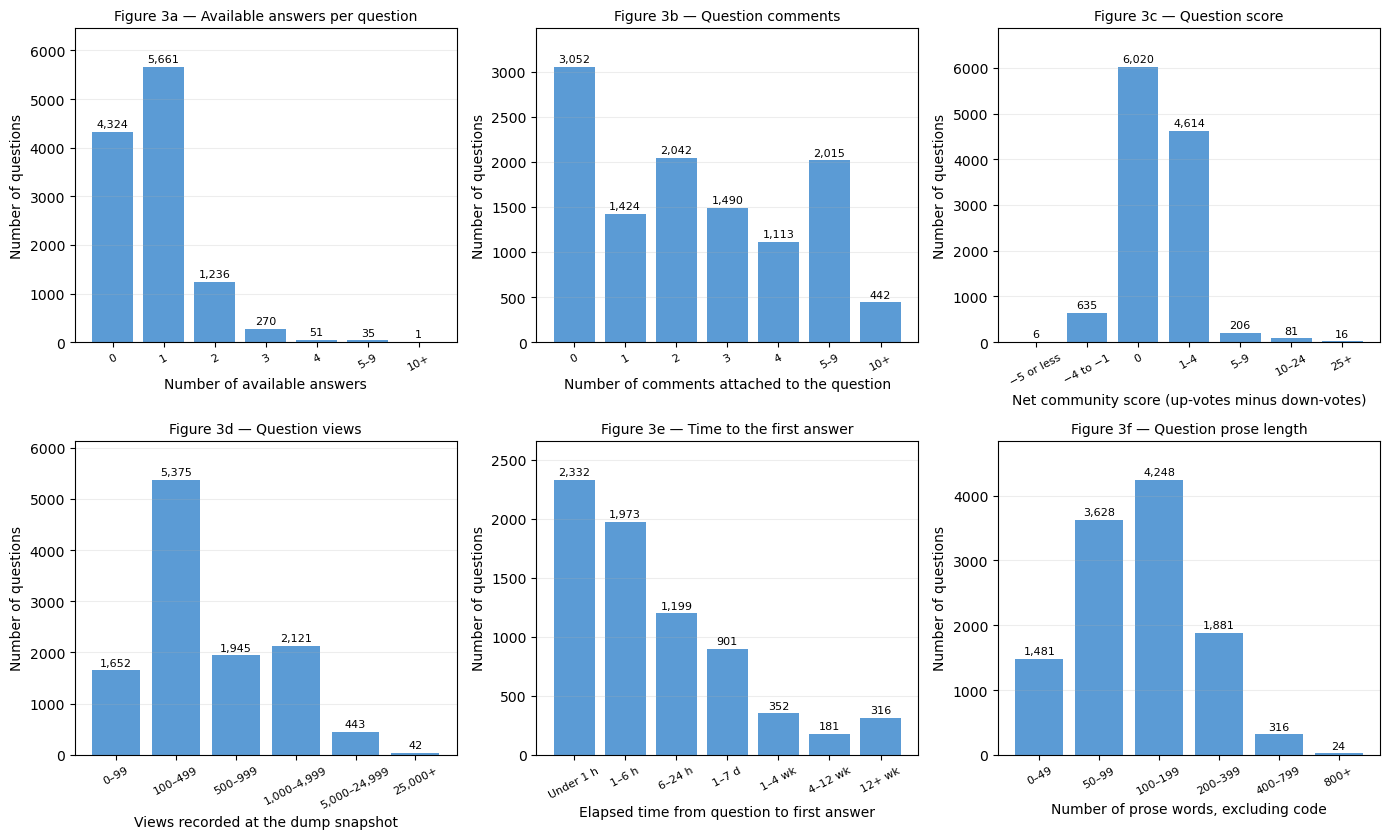

**Figure 3 interpretation**  
- **Figure 3a:** 4,324 questions (37.3%) have no available answer; the 10+ answer-group count is 1.  
- **Figure 3b:** 3,052 questions (26.4%) have no available question comment; the 10+ comment-group count is 442.  
- **Figure 3c:** The score-0 count is 6,020; the counts at −5 or lower and 25 or higher are 6 and 16.  
- **Figure 3d:** The count below 500 recorded views is 7,027; the 25,000+ count is 42.  
- **Figure 3e:** Among 7,254 answered questions, the within-24-hour count is 5,504 and the 12+-week count is 316.  
- **Figure 3f:** The count below 100 prose words is 5,109; the 800+ word count is 24.

In [6]:
def grouped_counts(values, bins, labels):
    """Count values in the readable ranges printed on a plot."""
    groups = pd.cut(values.dropna(), bins=bins, labels=labels, right=False)
    return groups.value_counts(sort=False)

answer_counts = grouped_counts(
    data["available_answer_count"],
    [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 9.5, np.inf],
    ["0", "1", "2", "3", "4", "5–9", "10+"],
)
comment_counts = grouped_counts(
    data["available_question_comment_count"],
    [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 9.5, np.inf],
    ["0", "1", "2", "3", "4", "5–9", "10+"],
)
score_counts = grouped_counts(
    data["question_score"],
    [-np.inf, -4.5, -0.5, 0.5, 4.5, 9.5, 24.5, np.inf],
    ["−5 or less", "−4 to −1", "0", "1–4", "5–9", "10–24", "25+"],
)
view_counts = grouped_counts(
    data["question_view_count"],
    [-0.5, 99.5, 499.5, 999.5, 4999.5, 24999.5, np.inf],
    ["0–99", "100–499", "500–999", "1,000–4,999", "5,000–24,999", "25,000+"],
)
delay_counts = grouped_counts(
    data["time_to_first_answer_hours"],
    [0, 1, 6, 24, 168, 672, 2016, np.inf],
    ["Under 1 h", "1–6 h", "6–24 h", "1–7 d", "1–4 wk", "4–12 wk", "12+ wk"],
)
word_counts = grouped_counts(
    data["question_word_count"],
    [-0.5, 49.5, 99.5, 199.5, 399.5, 799.5, np.inf],
    ["0–49", "50–99", "100–199", "200–399", "400–799", "800+"],
)

plots = [
    ("Figure 3a — Available answers per question", "Number of available answers", answer_counts),
    ("Figure 3b — Question comments", "Number of comments attached to the question", comment_counts),
    ("Figure 3c — Question score", "Net community score (up-votes minus down-votes)", score_counts),
    ("Figure 3d — Question views", "Views recorded at the dump snapshot", view_counts),
    ("Figure 3e — Time to the first answer", "Elapsed time from question to first answer", delay_counts),
    ("Figure 3f — Question prose length", "Number of prose words, excluding code", word_counts),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8.5))
for ax, (title, x_label, counts) in zip(axes.flat, plots):
    bars = ax.bar(counts.index.astype(str), counts.values, color="#5B9BD5")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Number of questions")
    ax.tick_params(axis="x", rotation=28, labelsize=8)
    ax.grid(axis="y", alpha=0.22)
    ax.bar_label(bars, labels=[f"{value:,}" for value in counts.values], padding=2, fontsize=8)
    ax.set_ylim(0, max(counts.max() * 1.14, 1))
plt.tight_layout()
plt.show()

answered_delays = int(delay_counts.sum())
interpretations = [
    f"- **Figure 3a:** {answer_counts['0']:,} questions ({answer_counts['0'] / len(data):.1%}) have no available answer; the 10+ answer-group count is {answer_counts['10+']:,}.",
    f"- **Figure 3b:** {comment_counts['0']:,} questions ({comment_counts['0'] / len(data):.1%}) have no available question comment; the 10+ comment-group count is {comment_counts['10+']:,}.",
    f"- **Figure 3c:** The score-0 count is {score_counts['0']:,}; the counts at −5 or lower and 25 or higher are {score_counts['−5 or less']:,} and {score_counts['25+']:,}.",
    f"- **Figure 3d:** The count below 500 recorded views is {view_counts['0–99'] + view_counts['100–499']:,}; the 25,000+ count is {view_counts['25,000+']:,}.",
    f"- **Figure 3e:** Among {answered_delays:,} answered questions, the within-24-hour count is {delay_counts['Under 1 h'] + delay_counts['1–6 h'] + delay_counts['6–24 h']:,} and the 12+-week count is {delay_counts['12+ wk']:,}.",
    f"- **Figure 3f:** The count below 100 prose words is {word_counts['0–49'] + word_counts['50–99']:,}; the 800+ word count is {word_counts['800+']:,}.",
]
display(Markdown("**Figure 3 interpretation**  \n" + "  \n".join(interpretations)))

## 5. Tags and response outcomes

A tag names the topic of a question. One question can have several tags, so tag totals overlap. Figure 4 shows frequent topics. Figure 5 compares answer and acceptance percentages for tags with enough questions to support a stable descriptive comparison.

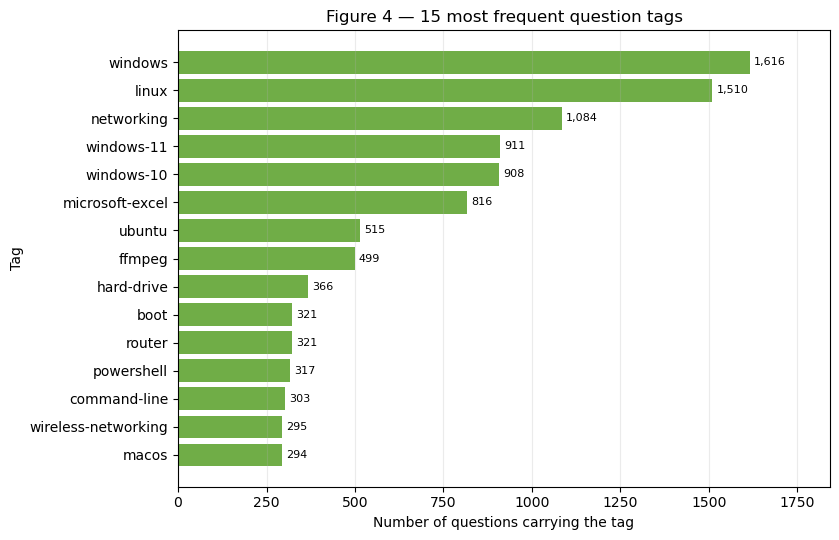

**Figure 4 interpretation.** **windows** is the most frequent tag, appearing on **1,616** of the **11,578** questions. Tag counts describe topic coverage; they provide context for later within-site comparisons.

In [7]:
tag_rows = (
    data[["question_id", "question_tags"]]
    .dropna(subset=["question_tags"])
    .assign(tag=lambda table: table["question_tags"].str.split(";"))
    .explode("tag")
)
tag_rows["tag"] = tag_rows["tag"].str.strip()
tag_rows = tag_rows[tag_rows["tag"] != ""]
tag_frequency = tag_rows["tag"].value_counts()
top_tags = tag_frequency.head(TOP_TAGS_TO_SHOW).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.barh(top_tags.index, top_tags.values, color="#70AD47")
ax.set_title(f"Figure 4 — {len(top_tags)} most frequent question tags")
ax.set_xlabel("Number of questions carrying the tag")
ax.set_ylabel("Tag")
ax.grid(axis="x", alpha=0.25)
ax.bar_label(bars, labels=[f"{value:,}" for value in top_tags.values], padding=3, fontsize=8)
ax.set_xlim(0, top_tags.max() * 1.14)
plt.tight_layout()
plt.show()

most_common_tag = tag_frequency.index[0]
display(Markdown(
    f"**Figure 4 interpretation.** **{most_common_tag}** is the most frequent tag, appearing on "
    f"**{tag_frequency.iloc[0]:,}** of the **{len(data):,}** questions. Tag counts describe topic coverage; "
    "they provide context for later within-site comparisons."
))

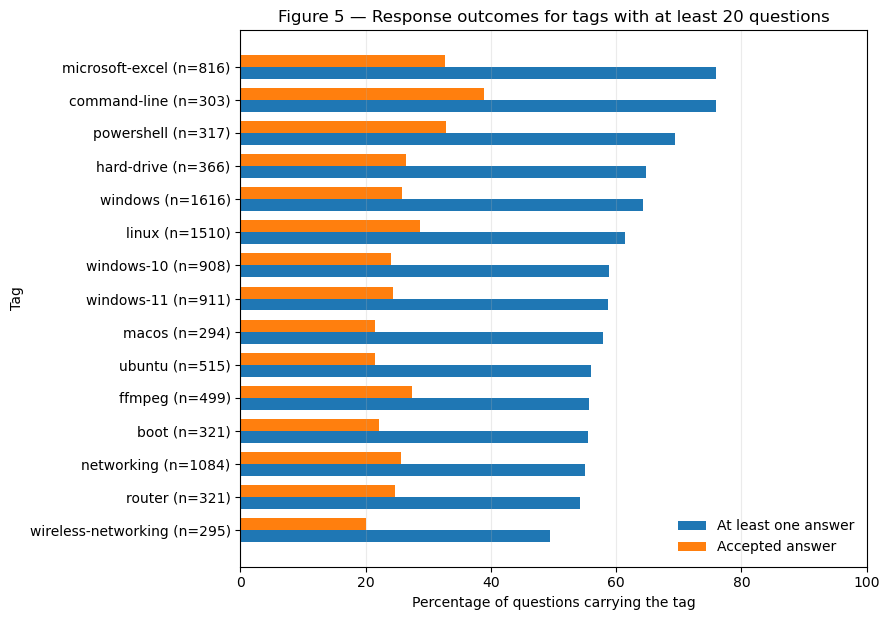

**Figure 5 interpretation.** Among the displayed tags, **microsoft-excel** has the highest answered share (76.0%) and **wireless-networking** has the lowest (49.5%). These percentages identify topic groups for closer reading and preserve each site's own community context.

In [8]:
tag_outcomes = tag_rows.merge(
    data[["question_id", "has_available_answer", "has_accepted_answer"]],
    on="question_id",
    how="left",
)
tag_summary = tag_outcomes.groupby("tag").agg(
    questions=("question_id", "nunique"),
    answered_percentage=("has_available_answer", "mean"),
    accepted_percentage=("has_accepted_answer", "mean"),
)
tag_summary[["answered_percentage", "accepted_percentage"]] *= 100
eligible_tags = (
    tag_summary[tag_summary["questions"] >= MIN_TAG_QUESTIONS]
    .sort_values("questions", ascending=False)
    .head(TOP_TAGS_TO_SHOW)
    .sort_values("answered_percentage")
)

if eligible_tags.empty:
    display(Markdown(
        f"**Figure 5 is unavailable.** No tag reaches the current minimum of "
        f"{MIN_TAG_QUESTIONS} questions. Lower `MIN_TAG_QUESTIONS` in the editable settings for a pilot table."
    ))
else:
    positions = np.arange(len(eligible_tags))
    fig, ax = plt.subplots(figsize=(9, max(4.5, 0.42 * len(eligible_tags))))
    ax.barh(positions - 0.18, eligible_tags["answered_percentage"], height=0.36, label="At least one answer")
    ax.barh(positions + 0.18, eligible_tags["accepted_percentage"], height=0.36, label="Accepted answer")
    tag_axis_labels = [f"{tag} (n={int(eligible_tags.loc[tag, 'questions'])})" for tag in eligible_tags.index]
    ax.set_yticks(positions, tag_axis_labels)
    ax.set_xlim(0, 100)
    ax.set_title(f"Figure 5 — Response outcomes for tags with at least {MIN_TAG_QUESTIONS} questions")
    ax.set_xlabel("Percentage of questions carrying the tag")
    ax.set_ylabel("Tag")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    highest = eligible_tags["answered_percentage"].idxmax()
    lowest = eligible_tags["answered_percentage"].idxmin()
    display(Markdown(
        f"**Figure 5 interpretation.** Among the displayed tags, **{highest}** has the highest answered share "
        f"({eligible_tags.loc[highest, 'answered_percentage']:.1f}%) and **{lowest}** has the lowest "
        f"({eligible_tags.loc[lowest, 'answered_percentage']:.1f}%). These percentages identify topic groups "
        "for closer reading and preserve each site's own community context."
    ))

## 6. Curated Spearman relationships

**What it is.** Spearman correlation checks whether two measurements tend to rise or fall together after replacing their raw values with ranks.

**How to read it.** Values approach `1` when both measurements rise together, `−1` when one rises as the other falls, and `0` when their ranked movement has little consistent pattern.

**What is displayed.** The calculation examines a curated set with one measure per concept. Figure 6 keeps pairs that satisfy both conditions: absolute correlation at least **`MIN_ABSOLUTE_RHO`** and Benjamini–Hochberg false-discovery-rate value at most **`FDR_ALPHA`**. Each heatmap row is one retained pair, which removes the diagonal and empty matrix cells. The image/link pair is excluded because Stack Exchange image markup commonly creates a link around an image. Correlation describes association and supports investigation. Causal conclusions require a separate study.

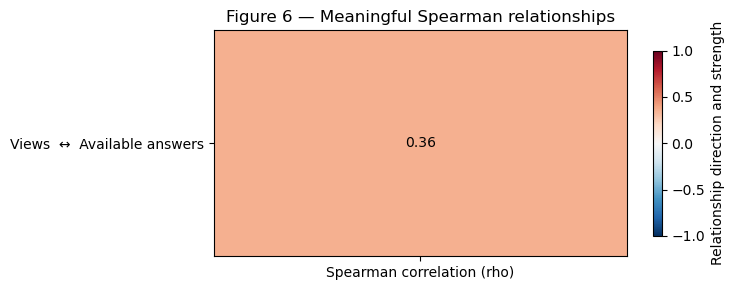

**Figure 6 interpretation**  
- **Views** and **Available answers** rise together (rho = 0.36, q < 1e-300, n = 11,578).  
- These relationships select questions and hypotheses for closer analysis. Causal interpretation requires a separate study.

In [9]:
correlation_labels = {
    "question_word_count": "Prose words",
    "code_line_count": "Code lines",
    "link_count": "Links",
    "image_count": "Images",
    "tag_count": "Tags",
    "question_score": "Question score",
    "question_view_count": "Views",
    "available_answer_count": "Available answers",
    "available_question_comment_count": "Question comments",
    "time_to_first_answer_hours": "Hours to first answer",
    "observation_days_at_dump": "Observation days",
}

structural_pairs = {frozenset(("link_count", "image_count"))}
pair_results = []
for first, second in combinations(correlation_labels, 2):
    if frozenset((first, second)) in structural_pairs:
        continue
    pair = data[[first, second]].dropna()
    if len(pair) < 20 or pair[first].nunique() < 2 or pair[second].nunique() < 2:
        continue
    rho, p_value = stats.spearmanr(pair[first], pair[second])
    pair_results.append({
        "first": first, "second": second, "rho": rho,
        "p_value": p_value, "observations": len(pair),
    })

correlations = pd.DataFrame(pair_results)
if not correlations.empty:
    correlations["q_value"] = stats.false_discovery_control(
        correlations["p_value"].to_numpy(), method="bh"
    )
    meaningful = correlations[
        (correlations["rho"].abs() >= MIN_ABSOLUTE_RHO)
        & (correlations["q_value"] <= FDR_ALPHA)
    ].copy()
else:
    meaningful = correlations.copy()

if meaningful.empty:
    display(Markdown(
        "**Figure 6 result.** No pair satisfies both display rules in this table. "
        "The empty figure result keeps the reported relationships evidence-based."
    ))
else:
    meaningful["pair_label"] = meaningful.apply(
        lambda row: f"{correlation_labels[row['first']]}  ↔  {correlation_labels[row['second']]}",
        axis=1,
    )
    meaningful = meaningful.reindex(
        meaningful["rho"].abs().sort_values(ascending=False).index
    )

    figure_height = max(3.0, 1.5 + 0.48 * len(meaningful))
    fig, ax = plt.subplots(figsize=(7.5, figure_height))
    image = ax.imshow(
        meaningful[["rho"]].to_numpy(),
        aspect="auto", vmin=-1, vmax=1, cmap="RdBu_r",
    )
    ax.set_yticks(range(len(meaningful)), meaningful["pair_label"])
    ax.set_xticks([0], ["Spearman correlation (rho)"])
    ax.set_title("Figure 6 — Meaningful Spearman relationships")
    for row_number, rho in enumerate(meaningful["rho"]):
        ax.text(0, row_number, f"{rho:.2f}", ha="center", va="center")
    color_bar = fig.colorbar(image, ax=ax, shrink=0.82)
    color_bar.set_label("Relationship direction and strength")
    plt.tight_layout()
    plt.show()

    lines = []
    for row in meaningful.head(3).itertuples():
        direction = "rise together" if row.rho > 0 else "move in opposite directions"
        q_text = "< 1e-300" if row.q_value == 0 else f"{row.q_value:.3g}"
        lines.append(
            f"- **{correlation_labels[row.first]}** and **{correlation_labels[row.second]}** "
            f"{direction} (rho = {row.rho:.2f}, q {q_text}, n = {row.observations:,})."
        )
    display(Markdown(
        "**Figure 6 interpretation**  \n" + "  \n".join(lines)
        + "  \n- These relationships select questions and hypotheses for closer analysis. Causal interpretation requires a separate study."
    ))

## 7. Questions worth reading

The final table replaces abstract outlier box plots with concrete questions. It selects long waits for a first answer and high question-comment counts, removes duplicates, and provides direct URLs. These are inspection candidates for qualitative analysis. Difficulty labels require a documented manual assessment.

In [10]:
long_waits = data.nlargest(MAX_CASES_TO_SHOW, "time_to_first_answer_hours").copy()
long_waits["selection_reason"] = "Long wait for first answer"
most_discussed = data.nlargest(MAX_CASES_TO_SHOW, "available_question_comment_count").copy()
most_discussed["selection_reason"] = "Many question comments"

cases = (
    pd.concat([long_waits, most_discussed], ignore_index=True)
    .drop_duplicates(subset="question_id")
    .head(MAX_CASES_TO_SHOW)
)
cases["question_title"] = cases["question_title"].fillna("").str.slice(0, 90)
cases_to_show = cases[[
    "selection_reason", "question_id", "question_title", "question_url",
    "available_answer_count", "available_question_comment_count",
    "time_to_first_answer_hours",
]].rename(columns={
    "selection_reason": "Why selected",
    "question_id": "Question ID",
    "question_title": "Question title (first 90 characters)",
    "question_url": "Question URL",
    "available_answer_count": "Available answers",
    "available_question_comment_count": "Question comments",
    "time_to_first_answer_hours": "Hours to first answer",
})
display(cases_to_show)

,Why selected,Question ID,Question title (first 90 characters),Question URL,Available answers,Question comments,Hours to first answer
0,Long wait for first answer,1828525,Windows 10 Insider Preview wants to update but...,https://superuser.com/questions/1828525,1,2,17792.086981
1,Long wait for first answer,1829318,Windows 11 iso file fails to mount,https://superuser.com/questions/1829318,2,2,17646.586113
2,Long wait for first answer,1824305,Can I downgrade Whisper AI's large model from ...,https://superuser.com/questions/1824305,1,2,17108.189180
3,Long wait for first answer,1841528,Improve Adblock performance by viewing recentl...,https://superuser.com/questions/1841528,1,3,16482.191782
4,Long wait for first answer,1835103,How to create a redacted PDF where the redacti...,https://superuser.com/questions/1835103,1,3,16128.686483
5,Long wait for first answer,1836457,How to remove individual header buttons in Thu...,https://superuser.com/questions/1836457,1,0,16093.653258
6,Long wait for first answer,1837310,System Volume OSD shows unwanted meta data & c...,https://superuser.com/questions/1837310,1,4,16034.999526
7,Long wait for first answer,1835796,Failed RDP connection - Failed to Start Remote...,https://superuser.com/questions/1835796,1,0,15999.884796


## 8. How to use these results

- Use Figures 1–3 to describe the corpus and human-response traces.
- Use Figures 4–5 to choose topic groups for within-site comparison.
- Use Figure 6 to formulate association hypotheses with explicit statistical controls.
- Read the questions in Section 7 before defining annotation categories.
- Build the human-difficulty label through a documented manual protocol.
- Evaluate model difficulty separately, then compare human and model outcomes in four groups: easy for both, difficult for both, difficult for humans, and difficult for the model.